# Model Training


## Objective

This notebook trains the first baseline model using the processed dataset created in `03_feature_engineering.ipynb`.

The goals are to:

- Load the processed modeling dataset
- Define baseline feature and target sets
- Build a leakage-aware train/validation split
- Train baseline regression models
- Evaluate performance on a held-out validation set
- Save trained artifacts for reproducibility

## Positioning Within the Challenge

This notebook establishes a **baseline supervised learning pipeline** on target-player rows.

It does **not yet replicate the official competition inference workflow**, but it provides:

- a reproducible training baseline,
- an internal benchmark for feature engineering,
- and a foundation for future improvements aligned with the challenge.

In [1]:
import sys
from pathlib import Path
import json
from datetime import datetime
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

sys.path.append(str(Path("..").resolve()))

from src.config import PROCESSED_DIR, MODELS_DIR, REPORTS_DIR

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

##  Load Processed Dataset

We begin by loading the processed baseline dataset created in `03_feature_engineering.ipynb`.

This dataset already includes:

- filtered target-player rows,
- cleaned player attributes,
- baseline movement variables,
- and target columns required for model training.

In [2]:
# Load processed dataset
input_path = PROCESSED_DIR / "baseline_train_v1.parquet"
df = pd.read_parquet(input_path)

print("Loaded dataset shape:", df.shape)
display(df.head())

# Load metadata (for traceability)
metadata_path = PROCESSED_DIR / "baseline_train_v1_metadata.json"

if metadata_path.exists():
    with open(metadata_path) as f:
        fe_metadata = json.load(f)
    print("\nFeature engineering metadata:")
    display(fe_metadata)

Loaded dataset shape: (152305, 21)


,game_id,play_id,nfl_id,frame_id,x,y,s,a,dir,o,absolute_yardline_number,player_weight,player_height_inches,player_age,is_moving_right,player_position,player_side,player_role,ball_land_x,ball_land_y,num_frames_output
0,2023090700,101,46137,1,51.32,20.69,0.31,0.49,79.43,267.68,42,204,73,26,1,SS,Defense,Defensive Coverage,63.259998,-0.22,21
1,2023090700,101,46137,2,51.35,20.66,0.36,0.74,118.07,268.66,42,204,73,26,1,SS,Defense,Defensive Coverage,63.259998,-0.22,21
2,2023090700,101,46137,3,51.39,20.63,0.44,0.76,130.89,269.78,42,204,73,26,1,SS,Defense,Defensive Coverage,63.259998,-0.22,21
3,2023090700,101,46137,4,51.43,20.61,0.48,0.62,134.50,269.78,42,204,73,26,1,SS,Defense,Defensive Coverage,63.259998,-0.22,21
4,2023090700,101,46137,5,51.48,20.58,0.54,0.44,129.79,269.06,42,204,73,26,1,SS,Defense,Defensive Coverage,63.259998,-0.22,21



Feature engineering metadata:


{'created_at': '2026-03-31T14:01:28.183716',
 'source_files_used': ['input_2023_w01.csv', 'input_2023_w02.csv'],
 'n_weeks_loaded': 2,
 'n_rows_raw': 574300,
 'n_rows_target': 152305,
 'n_rows_model': 152305,
 'n_columns_model': 21,
 'engineered_columns': ['player_height_inches',
  'player_age',
  'is_moving_right'],
 'target_columns': ['ball_land_x', 'ball_land_y', 'num_frames_output'],
 'notes': 'Baseline feature engineering dataset for target-player rows.'}

## Define Features and Targets

For this first baseline, we use a compact set of:

- movement variables,
- player attributes,
- contextual variables,
- and field-position information.

Identifier columns such as `game_id`, `play_id`, and `nfl_id` are retained for splitting and traceability, but excluded from the model inputs.

### Target Variables

We train two separate regression models to predict:

- `ball_land_x`
- `ball_land_y`

In [3]:
target_cols = ["ball_land_x", "ball_land_y"]

feature_cols = [
    "x",
    "y",
    "s",
    "a",
    "dir",
    "o",
    "absolute_yardline_number",
    "player_weight",
    "player_height_inches",
    "player_age",
    "is_moving_right",
    "player_position",
    "player_side",
    "player_role",
]

categorical_cols = [
    "player_position",
    "player_side",
    "player_role",
]

X = df[feature_cols].copy()
y_x = df["ball_land_x"].copy()
y_y = df["ball_land_y"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape (ball_land_x):", y_x.shape)
print("Target shape (ball_land_y):", y_y.shape)

print("\nCategorical columns:")
print(categorical_cols)

Feature matrix shape: (152305, 14)
Target shape (ball_land_x): (152305,)
Target shape (ball_land_y): (152305,)

Categorical columns:
['player_position', 'player_side', 'player_role']


## Missing Value Check

Before training, we inspect the final feature table for missing values.

This remains important even after EDA because:

- engineered features may introduce new missing values,
- filtered subsets may have different missingness patterns,
- and model behavior can be affected by incomplete inputs.

In [4]:
missing_percent = X.isnull().mean().sort_values(ascending=False)
display(missing_percent[missing_percent > 0])

Series([], dtype: float64)

##  Train / Validation Split

To reduce leakage, the dataset is split by `game_id` rather than by random row sampling.

This is important because rows within the same game may share strong contextual structure. A grouped split provides a more realistic estimate of generalization performance.

In [5]:
unique_games = df["game_id"].dropna().unique()
unique_games = np.sort(unique_games)

rng = np.random.default_rng(42)
shuffled_games = rng.permutation(unique_games)

split_idx = int(0.8 * len(shuffled_games))
train_games = set(shuffled_games[:split_idx])
valid_games = set(shuffled_games[split_idx:])

train_mask = df["game_id"].isin(train_games)
valid_mask = df["game_id"].isin(valid_games)

print("Number of unique games:", len(unique_games))
print("Training games:", len(train_games))
print("Validation games:", len(valid_games))

Number of unique games: 32
Training games: 25
Validation games: 7


## Feature Encoding

The baseline feature set includes categorical variables such as player position, player side, and player role.

Because `RandomForestRegressor` requires numerical input, these categorical variables are converted using **one-hot encoding** before model training.

In [6]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, dummy_na=True)

X_train = X_encoded.loc[train_mask].copy()
X_valid = X_encoded.loc[valid_mask].copy()

y_train_x = y_x.loc[train_mask].copy()
y_valid_x = y_x.loc[valid_mask].copy()

y_train_y = y_y.loc[train_mask].copy()
y_valid_y = y_y.loc[valid_mask].copy()

print("Encoded training shape:", X_train.shape)
print("Encoded validation shape:", X_valid.shape)
print("Training rows:", X_train.shape[0])
print("Validation rows:", X_valid.shape[0])

Encoded training shape: (121480, 32)
Encoded validation shape: (30825, 32)
Training rows: 121480
Validation rows: 30825


In [7]:
trained_feature_columns = list(X_train.columns)
print("Number of trained features:", len(trained_feature_columns))

Number of trained features: 32


## Baseline Model Selection

For this baseline, we use **RandomForestRegressor**, a robust ensemble method well suited for tabular data.

It provides:

- nonlinear modeling capability,
- robustness through ensemble averaging,
- and a strong baseline with minimal tuning.

We train two separate regression models:

- one for `ball_land_x`
- one for `ball_land_y`

This keeps the initial pipeline simple, interpretable, and easy to improve later.

In [8]:
model_x = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model_y = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

## Train Baseline Models

We now fit the two regression models on the training split.

In [9]:
model_x.fit(X_train, y_train_x)

RandomForestRegressor(max_depth=12, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [10]:
model_y.fit(X_train, y_train_y)

RandomForestRegressor(max_depth=12, n_estimators=200, n_jobs=-1,
                      random_state=42)

## Baseline Benchmark

Before interpreting the trained models, we compute a naïve benchmark.

This benchmark predicts the mean target value from the training set and provides a useful reference point for model performance.

In [11]:
baseline_pred_x = np.full_like(y_valid_x, y_train_x.mean(), dtype=float)
baseline_pred_y = np.full_like(y_valid_y, y_train_y.mean(), dtype=float)

baseline_metrics_x = {
    "MAE": mean_absolute_error(y_valid_x, baseline_pred_x),
    "RMSE": mean_squared_error(y_valid_x, baseline_pred_x, squared=False),
    "R2": r2_score(y_valid_x, baseline_pred_x),
}

baseline_metrics_y = {
    "MAE": mean_absolute_error(y_valid_y, baseline_pred_y),
    "RMSE": mean_squared_error(y_valid_y, baseline_pred_y, squared=False),
    "R2": r2_score(y_valid_y, baseline_pred_y),
}

baseline_metrics_df = pd.DataFrame({
    "ball_land_x_baseline": baseline_metrics_x,
    "ball_land_y_baseline": baseline_metrics_y,
})

display(baseline_metrics_df)

,ball_land_x_baseline,ball_land_y_baseline
MAE,20.976016,13.747809
RMSE,25.432954,15.854705
R2,-0.000529,-0.000052


##  Generate Validation Predictions

After training, we generate predictions on the validation set for both target variables.

In [12]:
pred_valid_x = model_x.predict(X_valid)
pred_valid_y = model_y.predict(X_valid)

pred_df = pd.DataFrame({
    "ball_land_x_true": y_valid_x.values,
    "ball_land_x_pred": pred_valid_x,
    "ball_land_y_true": y_valid_y.values,
    "ball_land_y_pred": pred_valid_y,
}, index=y_valid_x.index)

pred_df["error_x"] = pred_df["ball_land_x_pred"] - pred_df["ball_land_x_true"]
pred_df["error_y"] = pred_df["ball_land_y_pred"] - pred_df["ball_land_y_true"]

display(pred_df.head())

,ball_land_x_true,ball_land_x_pred,ball_land_y_true,ball_land_y_pred,error_x,error_y
6371,55.57,53.863232,27.799999,36.742392,-1.706768,8.942392
6372,55.57,53.863232,27.799999,36.892358,-1.706768,9.092358
6373,55.57,53.863232,27.799999,37.293605,-1.706768,9.493606
6374,55.57,53.863232,27.799999,37.276076,-1.706768,9.476077
6375,55.57,53.863232,27.799999,37.470348,-1.706768,9.670349


##  Validation Performance

We evaluate the baseline models using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² score

These metrics do not replace the official competition evaluation pipeline, but they provide a strong internal benchmark for comparing models and feature sets during development.

In [13]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "R2": r2_score(y_true, y_pred),
    }

metrics_x = regression_metrics(y_valid_x, pred_valid_x)
metrics_y = regression_metrics(y_valid_y, pred_valid_y)

metrics_df = pd.DataFrame({
    "ball_land_x_model": metrics_x,
    "ball_land_y_model": metrics_y,
})

display(metrics_df)

,ball_land_x_model,ball_land_y_model
MAE,6.835385,7.563908
RMSE,9.061241,9.618264
R2,0.872998,0.631956


##  Model vs Naïve Baseline Comparison

To assess whether the trained models add real value, we compare them against the naïve benchmark.

In [14]:
comparison_df = pd.concat([baseline_metrics_df, metrics_df], axis=1)
display(comparison_df)

,ball_land_x_baseline,ball_land_y_baseline,ball_land_x_model,ball_land_y_model
MAE,20.976016,13.747809,6.835385,7.563908
RMSE,25.432954,15.854705,9.061241,9.618264
R2,-0.000529,-0.000052,0.872998,0.631956


##  Prediction Diagnostics

To better understand model behavior, we compare predicted values against true values on the validation set.

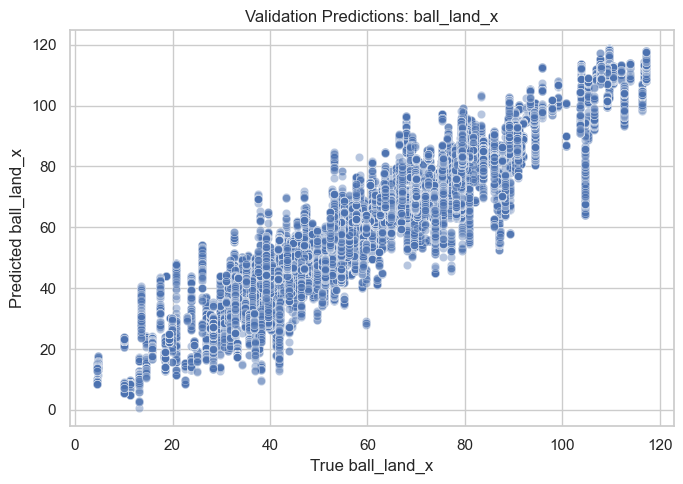

In [15]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_valid_x, y=pred_valid_x, alpha=0.4)
plt.title("Validation Predictions: ball_land_x")
plt.xlabel("True ball_land_x")
plt.ylabel("Predicted ball_land_x")
plt.tight_layout()
plt.show()

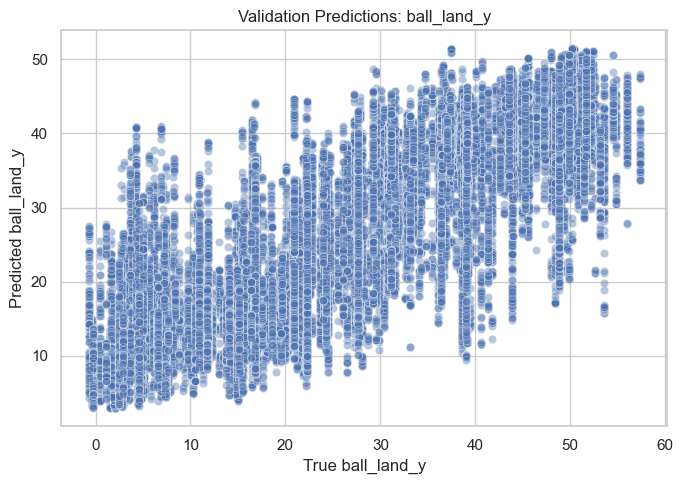

In [16]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_valid_y, y=pred_valid_y, alpha=0.4)
plt.title("Validation Predictions: ball_land_y")
plt.xlabel("True ball_land_y")
plt.ylabel("Predicted ball_land_y")
plt.tight_layout()
plt.show()

##  Feature Importance

We inspect feature importance to understand which inputs contribute most to the predictions.

Because categorical variables were one-hot encoded, we examine:

- raw feature importance at the encoded-column level,
- grouped feature importance at the original feature-family level.

In [17]:
importance_x = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_x.feature_importances_
}).sort_values("importance", ascending=False)

importance_y = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_y.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 10 features for ball_land_x:")
display(importance_x.head(10))

print("Top 10 features for ball_land_y:")
display(importance_y.head(10))

Top 10 features for ball_land_x:


,feature,importance
0,x,0.859949
10,is_moving_right,0.054038
6,absolute_yardline_number,0.027249
1,y,0.011620
7,player_weight,0.011247
9,player_age,0.007797
5,o,0.006160
8,player_height_inches,0.005538
4,dir,0.004427
2,s,0.004417


Top 10 features for ball_land_y:


,feature,importance
1,y,0.720459
4,dir,0.084446
6,absolute_yardline_number,0.038213
7,player_weight,0.031005
0,x,0.026628
2,s,0.023205
9,player_age,0.018445
5,o,0.014047
8,player_height_inches,0.013168
3,a,0.007139


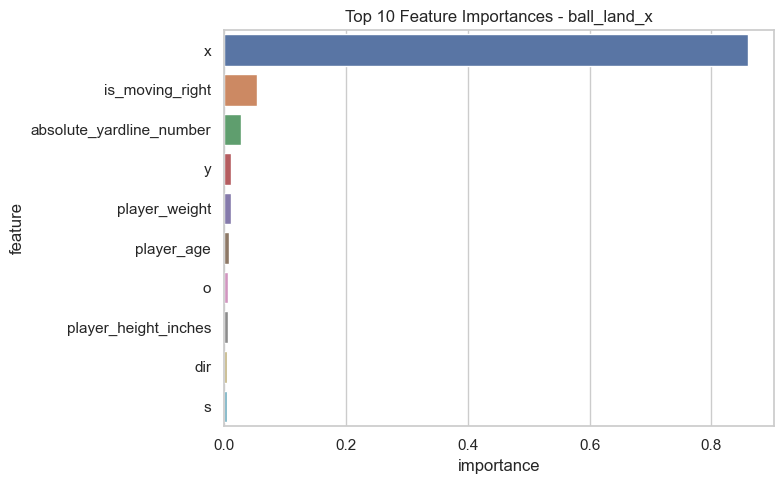

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_x.head(10), x="importance", y="feature")
plt.title("Top 10 Feature Importances - ball_land_x")
plt.tight_layout()
plt.show()

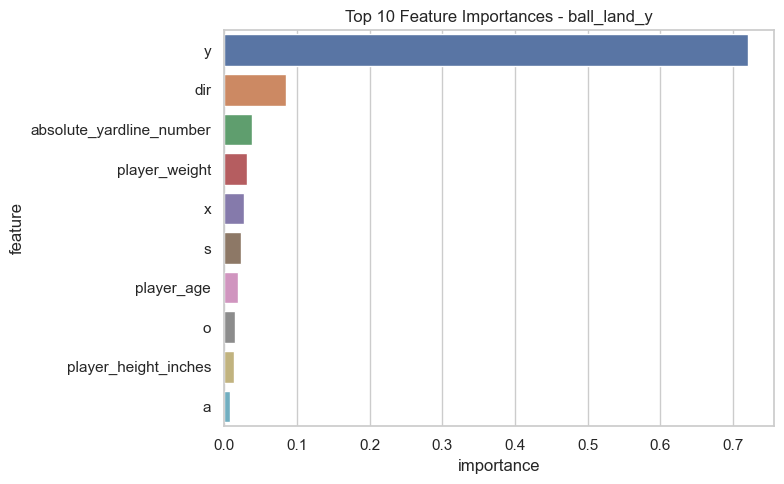

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_y.head(10), x="importance", y="feature")
plt.title("Top 10 Feature Importances - ball_land_y")
plt.tight_layout()
plt.show()

##  Grouped Feature Importance

Since one-hot encoding expands categorical variables into many columns, grouped feature importance provides a cleaner interpretation of the original feature families.

In [20]:
importance_x["base_feature"] = importance_x["feature"].str.split("_").str[0]
importance_y["base_feature"] = importance_y["feature"].str.split("_").str[0]

importance_x_grouped = (
    importance_x.groupby("base_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

importance_y_grouped = (
    importance_y.groupby("base_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("Top grouped features for ball_land_x:")
display(importance_x_grouped.head(10))

print("Top grouped features for ball_land_y:")
display(importance_y_grouped.head(10))

Top grouped features for ball_land_x:


base_feature
x           0.859949
is          0.054038
player      0.031478
absolute    0.027249
y           0.011620
o           0.006160
dir         0.004427
s           0.004417
a           0.000663
Name: importance, dtype: float64

Top grouped features for ball_land_y:


base_feature
y           0.720459
dir         0.084446
player      0.084394
absolute    0.038213
x           0.026628
s           0.023205
o           0.014047
a           0.007139
is          0.001469
Name: importance, dtype: float64

## Save Models and Training Artifacts

To keep the project reproducible and traceable, we save:

- the trained models,
- the trained feature columns,
- validation predictions,
- and metadata describing the training run.

In [21]:
run_dir = MODELS_DIR / "baseline_v1"
run_dir.mkdir(parents=True, exist_ok=True)

model_x_path = run_dir / "model_ball_land_x.pkl"
model_y_path = run_dir / "model_ball_land_y.pkl"
features_path = run_dir / "feature_columns.json"
metadata_path = run_dir / "training_metadata.json"
predictions_path = run_dir / "validation_predictions.parquet"

joblib.dump(model_x, model_x_path)
joblib.dump(model_y, model_y_path)

trained_feature_columns = list(X_train.columns)

with open(features_path, "w") as f:
    json.dump(trained_feature_columns, f, indent=2)

pred_df.to_parquet(predictions_path, index=False)

metadata = {
    "created_at": datetime.now().isoformat(),
    "input_dataset": str(input_path),
    "n_rows_total": int(df.shape[0]),
    "n_rows_train": int(X_train.shape[0]),
    "n_rows_valid": int(X_valid.shape[0]),
    "target_columns": target_cols,
    "feature_columns_raw": feature_cols,
    "feature_columns_trained": trained_feature_columns,
    "categorical_columns": categorical_cols,
    "metrics_ball_land_x": metrics_x,
    "metrics_ball_land_y": metrics_y,
    "baseline_metrics_ball_land_x": baseline_metrics_x,
    "baseline_metrics_ball_land_y": baseline_metrics_y,
    "model_type": "RandomForestRegressor",
    "model_params": model_x.get_params(),
    "notes": "Baseline RandomForest models trained on processed target-player rows with one-hot encoded categorical variables."
}

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model_x to:", model_x_path)
print("Saved model_y to:", model_y_path)
print("Saved features to:", features_path)
print("Saved metadata to:", metadata_path)
print("Saved validation predictions to:", predictions_path)

Saved model_x to: C:\Users\jmontanez\Documents\nfl-big-data-bowl-2026\models\baseline_v1\model_ball_land_x.pkl
Saved model_y to: C:\Users\jmontanez\Documents\nfl-big-data-bowl-2026\models\baseline_v1\model_ball_land_y.pkl
Saved features to: C:\Users\jmontanez\Documents\nfl-big-data-bowl-2026\models\baseline_v1\feature_columns.json
Saved metadata to: C:\Users\jmontanez\Documents\nfl-big-data-bowl-2026\models\baseline_v1\training_metadata.json
Saved validation predictions to: C:\Users\jmontanez\Documents\nfl-big-data-bowl-2026\models\baseline_v1\validation_predictions.parquet


## Summary

In this notebook, we developed the first baseline modeling pipeline.

We:

- loaded the processed dataset,
- defined feature and target variables,
- encoded categorical features,
- split the data by game to reduce leakage,
- trained two Random Forest models,
- compared performance against a naïve benchmark,
- analyzed feature importance,
- and saved trained artifacts for reproducibility.

This notebook establishes a reproducible baseline for the project.

Future improvements will focus on:

- richer spatial interaction features,
- temporal aggregation,
- sequence-aware modeling,
- and closer alignment with the official competition inference workflow.